# Task 9 — Rejection / abstention for the prototype classifier

A prototype classifier can be forced to answer every candidate, or allowed to abstain. This
notebook adds the second option and measures the trade-off — including the unattractive end of it.

**The dataset is synthetic.** Coverage and accepted-accuracy trade-offs measured here are
properties of a fitted model on simulated data, nothing biological. No biological or clinical
validity is claimed.

## The rejection score

The Task 4 prototype margin, **normalised** so one threshold grid is meaningful across folds:

```
margin(x) = (d_implausible − d_plausible) / (d_implausible + d_plausible + eps)
```

where `d_c` is the squared Euclidean distance from `x` to prototype `c` in standardized space. The
sign carries the predicted class, so one number does both jobs:

```
predict plausible  iff  margin > 0
reject             iff  |margin| < threshold
```

Normalising matters: the raw margin's scale depends on how far a sample sits from the prototypes,
so a distant-but-confident sample can look ambiguous purely because it is far away. The normalised
form is a dimensionless relative gap, bounded in (−1, 1).

> **This is not a probability and not a calibration claim.** The margin is a discriminative score,
> not a calibrated `P(plausible)`. Brier is reported only as a descriptive consequence of the fixed
> 0.5 decision rule.

## No threshold is selected

The grid is **predeclared**: 0.00, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50. Every point is
reported. None is chosen, recommended, or treated as optimal — picking one after seeing results
would be selecting it on the reporting folds. **The deliverable is the curve, and the reader picks
an operating point knowingly.** The 0.00 and 0.50 ends are included so the no-rejection baseline and
the extreme low-coverage regime are both visible.

## The control that decides whether this works

Rejecting fewer samples raises accepted-accuracy **for any rule whatsoever** — the accepted set is
smaller, so the easy remainder is a bigger share of it. So for every threshold, the same *number* of
samples is also rejected **at random**, 2000 times with a fixed seed, and the mean is reported. Only
the gap between margin-based and matched-random acceptance says whether margin-based rejection
identifies hard cases or merely shrinks the pool.

## Base model

The plain Task 4 prototype. **Not** the Task 5 relevance-weighted model, which showed no benefit, and
no M1/M2/M3 prior. The purpose is to characterise the reject option itself.

## Headline

Margin-based rejection raises accepted-accuracy monotonically and beats matched random rejection at
every threshold by a wide margin, and error rate falls monotonically with `|margin|`. The trade-off
is real though: most of the gain requires giving up substantial coverage.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "rejection.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import baseline
import cv_protocol
import prototype_model as P
import rejection as R
import validation_checks as V

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

candidates = V.load_candidates()      # model-facing only
rej = json.loads((ROOT / "results" / "rejection_cv.json").read_text())
print("candidates:", candidates.shape)
print("fingerprint:", rej["protocol"]["fold_fingerprint"],
      "| verified identical:", rej["protocol"]["folds_verified_identical"])
print("base model:", rej["protocol"]["base_model"])
print("threshold selection:", rej["protocol"]["threshold_selection"])
print("calibration claim:", rej["protocol"]["calibration_claim"])

candidates: (800, 14)
fingerprint: 9b587aa3d19a36f7 | verified identical: True
base model: plain nearest prototype (Task 4), no relevance weights, no M1/M2/M3 prior
threshold selection: NONE. The grid is predeclared and every point is reported. No threshold is chosen, recommended, or treated as optimal, so no result here is selected on the reporting folds.
calibration claim: NONE. The margin is a discriminative score, not a calibrated P(plausible). Brier is reported as a descriptive consequence of the fixed 0.5 rule only.


## 1. Protocol

Identical folds (`9b587aa3d19a36f7`), asserted in code. Scaling refit inside every training fold;
prototypes are training-fold class means. Margins below are **out-of-fold**, so no sample is scored
by a model that saw it.

In [2]:
rows = [{"setting": k, "value": str(v)[:130]} for k, v in rej["protocol"].items()
        if k not in ("threshold_grid",)]
pd.DataFrame(rows)

,setting,value
0,name,stratified 5-fold cross-validation (shared wit...
1,role,PRIMARY
2,n_splits,5
3,random_state,0
4,fold_fingerprint,9b587aa3d19a36f7
5,folds_verified_identical,True
6,base_model,"plain nearest prototype (Task 4), no relevance..."
7,rejection_score,normalised margin = (d_implausible - d_plausib...
8,predictive_score,Task 4 signed score = sqrt(d_implausible) - sq...
9,decision_rule,predict plausible iff margin > 0; reject iff |...


In [3]:
# Verify zero-rejection Task 9 reproduces Task 4 exactly.
chk = rej["task4_reproduction_check"]
print(chk["note"], "\n")
pd.DataFrame([
    {"metric": k, "Task 4": chk["checked"][k], "Task 9 at threshold 0.00": chk["task9_at_zero_rejection"][k],
     "abs difference": abs(chk["checked"][k] - chk["task9_at_zero_rejection"][k])}
    for k in chk["checked"]
]).round(12)
print(f"\nmax abs difference: {chk['max_abs_difference']:.2e}   reproduces_task4: {chk['reproduces_task4']}")

Task 9 at threshold 0.00 accepts every sample and therefore must equal Task 4 exactly, aggregating per fold in the same way. It does, to within floating point. This check is what guarantees the rejection analysis did not silently change the base model. 


max abs difference: 0.00e+00   reproduces_task4: True


In [4]:
o = rej["overall"]
print(f"out-of-fold margins over all {o['n']} samples")
print(f"  range          [{o['margin_min']:.4f}, {o['margin_max']:.4f}]")
print(f"  sd             {o['margin_sd']:.4f}")
print(f"  accuracy (no rejection) {o['accuracy_all_samples']:.4f}")
print(f"  AUROC   (no rejection) {o['auroc_all_samples']:.4f}   <- Task 4 score, unchanged")
print("\n  reference from earlier tasks on the same folds: P0 AUROC 0.8276, accuracy 0.7512.")
print(f"  {o['rejection_score']}")
print(f"  {o['predictive_score']}")
print("\n  The pooled AUROC here (0.8274) differs from Task 4's fold-averaged 0.8276")
print("  only because this line is pooled and that one averages per fold; the")
print("  assertion above compares like with like.")

out-of-fold margins over all 800 samples
  range          [-0.5648, 0.5215]
  sd             0.2327
  accuracy (no rejection) 0.7512
  AUROC   (no rejection) 0.8274   <- Task 4 score, unchanged

  reference from earlier tasks on the same folds: P0 AUROC 0.8276, accuracy 0.7512.
  normalised margin, used only to decide rejection
  Task 4 signed score, used for AUROC and Brier

  The pooled AUROC here (0.8274) differs from Task 4's fold-averaged 0.8276
  only because this line is pooled and that one averages per fold; the
  assertion above compares like with like.


## 2. Coverage–performance curve

In [5]:
rows = []
for row in rej["per_threshold"]:
    p, c = row["pooled"], row["random_control"]
    rows.append({
        "threshold": p["threshold"],
        "coverage": p["coverage"],
        "rejection rate": p["rejection_rate"],
        "n accepted": p["n_accepted"],
        "n rejected": p["n_rejected"],
        "accepted accuracy": p["accepted_accuracy"],
        "accepted bal acc": p["accepted_balanced_accuracy"],
        "accepted AUROC": p["accepted_auroc"],
        "accepted F1": p["accepted_f1"],
        "accepted Brier": p["accepted_brier"],
        "err rate rejected": p["error_rate_rejected"],
        "err rate accepted": p["error_rate_accepted"],
    })
curve = pd.DataFrame(rows)
curve

,threshold,coverage,rejection rate,n accepted,n rejected,accepted accuracy,accepted bal acc,accepted AUROC,accepted F1,accepted Brier,err rate rejected,err rate accepted
0,0.00,1.00000,0.00000,800,0,0.751250,0.751923,0.827385,0.710335,0.179332,NaN,0.248750
1,0.02,0.94750,0.05250,758,42,0.773087,0.773951,0.834663,0.735385,0.175295,0.642857,0.226913
2,0.05,0.87250,0.12750,698,102,0.786533,0.788845,0.844014,0.751252,0.169602,0.490196,0.213467
3,0.10,0.76250,0.23750,610,190,0.801639,0.802041,0.858876,0.765049,0.160652,0.410526,0.198361
4,0.15,0.63625,0.36375,509,291,0.829077,0.827258,0.875224,0.796253,0.148304,0.384880,0.170923
5,0.20,0.49000,0.51000,392,408,0.854592,0.852749,0.892116,0.828829,0.134096,0.348039,0.145408
6,0.30,0.22375,0.77625,179,621,0.871508,0.866538,0.899485,0.843537,0.121059,0.283414,0.128492
7,0.40,0.05625,0.94375,45,755,0.888889,0.896761,0.929150,0.897959,0.108147,0.256954,0.111111
8,0.50,0.00625,0.99375,5,795,0.800000,0.833333,0.666667,0.800000,0.162190,0.249057,0.200000


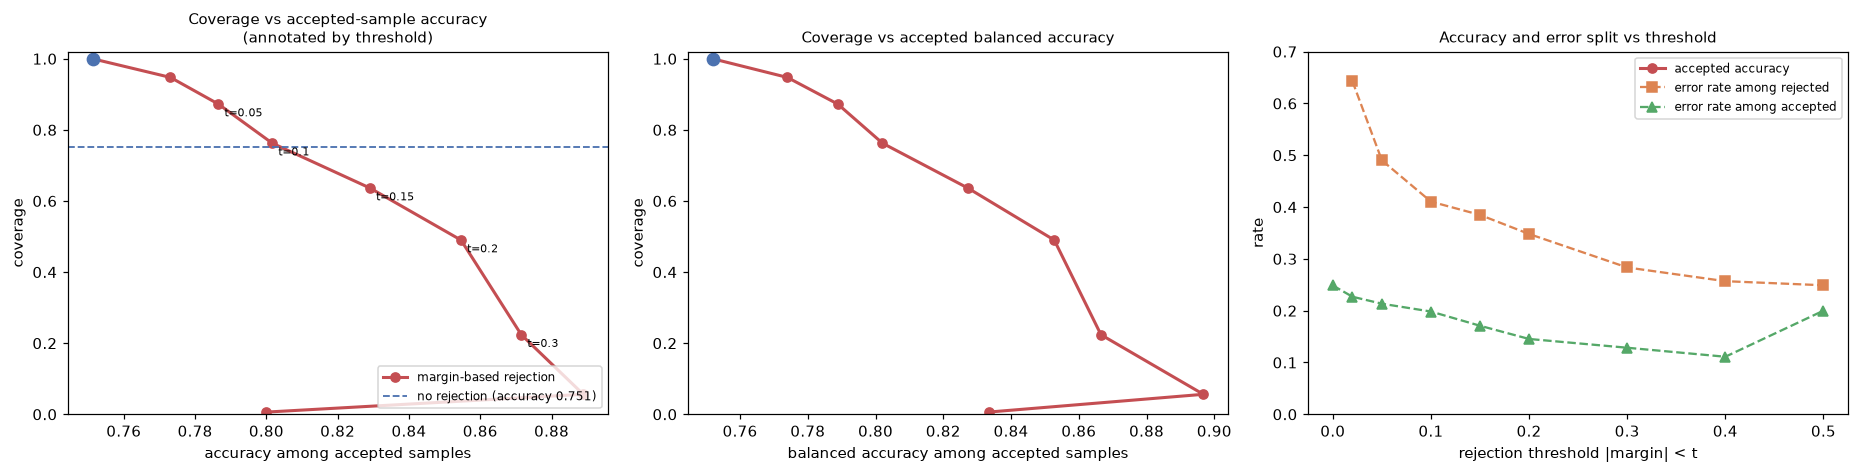

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
cov = curve["coverage"]
acc = curve["accepted accuracy"]
bal = curve["accepted bal acc"]
thr = curve["threshold"]

ax = axes[0]
ax.plot(acc, cov, "o-", color="#C44E52", lw=2, label="margin-based rejection")
ax.axhline(acc.iloc[0], color="#4C72B0", ls="--", lw=1.2,
           label=f"no rejection (accuracy {acc.iloc[0]:.3f})")
ax.plot([acc.iloc[0]], [1.0], "o", color="#4C72B0", ms=8)
for t, a, c in zip(thr, acc, cov):
    if t in (0.05, 0.10, 0.15, 0.20, 0.30):
        ax.annotate(f"t={t}", (a, c), fontsize=7, xytext=(4, -8), textcoords="offset points")
ax.set_xlabel("accuracy among accepted samples")
ax.set_ylabel("coverage")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Coverage vs accepted-sample accuracy\n(annotated by threshold)", fontsize=10)

ax = axes[1]
ax.plot(bal, cov, "o-", color="#C44E52", lw=2)
ax.plot([bal.iloc[0]], [1.0], "o", color="#4C72B0", ms=8)
ax.set_xlabel("balanced accuracy among accepted samples")
ax.set_ylabel("coverage")
ax.set_ylim(0, 1.02)
ax.set_title("Coverage vs accepted balanced accuracy", fontsize=10)

ax = axes[2]
ax.plot(thr, acc, "o-", color="#C44E52", lw=2, label="accepted accuracy")
ax.plot(thr, curve["err rate rejected"], "s--", color="#DD8452", lw=1.5,
        label="error rate among rejected")
ax.plot(thr, curve["err rate accepted"], "^--", color="#55A868", lw=1.5,
        label="error rate among accepted")
ax.set_xlabel("rejection threshold |margin| < t")
ax.set_ylabel("rate")
ax.set_ylim(0, 0.7)
ax.legend(fontsize=8)
ax.set_title("Accuracy and error split vs threshold", fontsize=10)
plt.show()

The curve is **monotone**: accepted-accuracy rises at every step of the grid, from 0.7512 with no
rejection to 0.8889 at t = 0.40. The error rate among accepted samples falls from 0.2488 to
0.1111, while the error rate among rejected samples stays high throughout (0.643 → 0.257) — never
dropping to the accepted-case level, which is the signature of rejection that actually targets hard
cases.

**The trade-off is real and worth stating plainly.** To get from 0.7512 to 0.8016 accepted-accuracy
costs 24 percentage points of coverage (1.00 → 0.76). To reach 0.8546 you keep only 49% of samples.
Anyone deploying this would be discarding half their candidates to buy 10 points of accuracy on the
rest, and that is a decision about use, not about modelling.

## 3. Matched random rejection — the control

In [7]:
rows = []
for row in rej["per_threshold"]:
    p, c = row["pooled"], row["random_control"]
    rows.append({
        "threshold": p["threshold"],
        "coverage": p["coverage"],
        "n rejected": p["n_rejected"],
        "margin accepted acc": p["accepted_accuracy"],
        "random accepted acc": c["mean"],
        "random sd": c["std"],
        "GAIN over random": row["margin_gain_over_random"],
    })
control = pd.DataFrame(rows)
# Gain expressed in units of the control's own variability. Computed per
# threshold, and only where the control has a meaningful sd.
control["gain / control sd"] = np.where(
    (control["random sd"] > 1e-9) & control["GAIN over random"].notna(),
    control["GAIN over random"] / control["random sd"],
    np.nan,
)
control
control

,threshold,coverage,n rejected,margin accepted acc,random accepted acc,random sd,GAIN over random,gain / control sd
0,0.00,1.00000,0,0.751250,0.751250,0.000000,0.000000,NaN
1,0.02,0.94750,42,0.773087,0.751370,0.003660,0.021717,5.933328
2,0.05,0.87250,102,0.786533,0.751337,0.005910,0.035196,5.955567
3,0.10,0.76250,190,0.801639,0.751226,0.008649,0.050413,5.828947
4,0.15,0.63625,291,0.829077,0.751314,0.011709,0.077762,6.641332
5,0.20,0.49000,408,0.854592,0.751441,0.015929,0.103151,6.475756
6,0.30,0.22375,621,0.871508,0.751450,0.028710,0.120059,4.181782
7,0.40,0.05625,755,0.888889,0.750678,0.063302,0.138211,2.183373
8,0.50,0.00625,795,0.800000,0.750600,0.196007,0.049400,0.252031


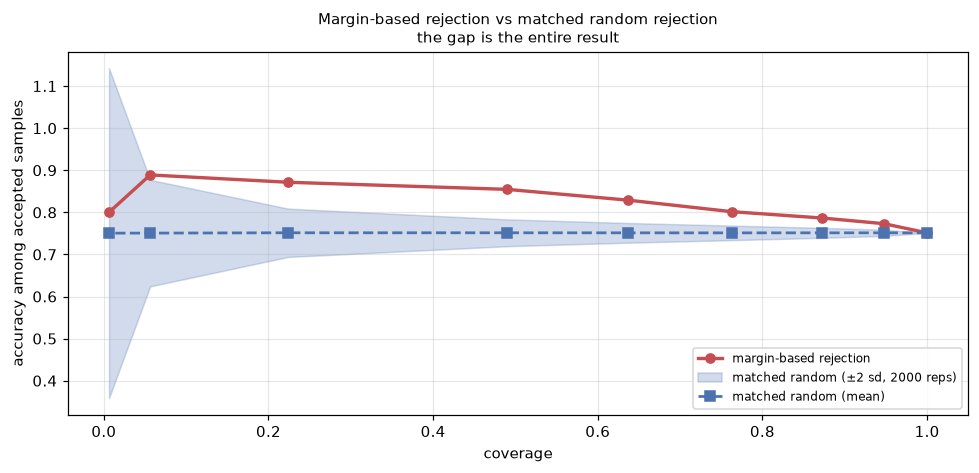

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(control["coverage"], control["margin accepted acc"], "o-",
        color="#C44E52", lw=2.2, label="margin-based rejection")
band = np.array(control["random accepted acc"], dtype=float)
sd = np.array([0.0 if s is None else s for s in control["random sd"]], dtype=float)
ax.fill_between(control["coverage"], band - 2 * sd, band + 2 * sd,
                color="#4C72B0", alpha=0.25, label="matched random (±2 sd, 2000 reps)")
ax.plot(control["coverage"], band, "s--", color="#4C72B0", lw=1.8,
        label="matched random (mean)")
ax.set_xlabel("coverage")
ax.set_ylabel("accuracy among accepted samples")
ax.set_title("Margin-based rejection vs matched random rejection\n"
             "the gap is the entire result", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
plt.show()

### Margin-based rejection beats matched random rejection at every threshold

| threshold | coverage | margin acc | random acc | random sd | **gain** |
|---|---|---|---|---|---|
| 0.05 | 0.873 | 0.7865 | 0.7513 | 0.0059 | **+0.0352** |
| 0.10 | 0.763 | 0.8016 | 0.7512 | 0.0086 | **+0.0504** |
| 0.15 | 0.636 | 0.8291 | 0.7513 | 0.0117 | **+0.0778** |
| 0.20 | 0.490 | 0.8546 | 0.7514 | 0.0159 | **+0.1032** |
| 0.30 | 0.224 | 0.8715 | 0.7514 | 0.0287 | **+0.1201** |
| 0.40 | 0.056 | 0.8889 | 0.7507 | 0.0633 | **+0.1382** |

The random control sits **flat at ~0.751 across the entire range** — as it must, since randomly
dropping any fixed fraction leaves accuracy essentially unchanged. The margin-based curve climbs to
0.889.

**Margin-based rejection gives higher accepted-sample accuracy than the mean matched-random
rejection control at every tested nonzero threshold.** That is the claim the control supports, and
it is the comparison that separates "rejection identifies difficult cases" from "rejecting fewer
samples raises accuracy".

**On expressing the gain in units of the control's variability** — the ratio is *not* uniformly
large, so it is worth being exact rather than quoting a favourable subset:

| threshold | gain | control sd | gain / sd |
|---|---|---|---|
| 0.05 | +0.0352 | 0.0059 | ~5.9× |
| 0.10 | +0.0504 | 0.0086 | ~5.8× |
| 0.15 | +0.0778 | 0.0117 | ~6.6× |
| 0.20 | +0.1032 | 0.0159 | ~6.5× |
| 0.30 | +0.1201 | 0.0287 | ~4.2× |
| 0.40 | +0.1382 | 0.0633 | **~2.2×** |

The ratio **falls to about 2.2 at t = 0.40** as the control's own spread widens. So the honest
characterisation is: the gain is large and unambiguous in the moderate-coverage regime, and while it
remains positive and larger than the control's noise at the most aggressive threshold, it is
markedly less decisive there — consistent with 5.6% coverage being a regime where both quantities
are themselves unstable.

## 4. Are rejected cases genuinely harder?

In [9]:
q = pd.DataFrame(rej["ambiguity_profile"]["quintiles"])
print(rej["ambiguity_profile"]["note"], "\n")
q

Descriptive, observable features only. Not used to select a threshold. Groups are quintiles of |margin|, so group 1 holds the most ambiguous samples and group 5 the clearest. 



,abs_margin_quintile,n,mean_abs_margin,error_rate,plausible_rate
0,1,160,0.039388,0.42500,0.38125
1,2,160,0.125048,0.33750,0.41875
2,3,160,0.196437,0.22500,0.38750
3,4,160,0.269772,0.11250,0.41250
4,5,160,0.374394,0.14375,0.41875


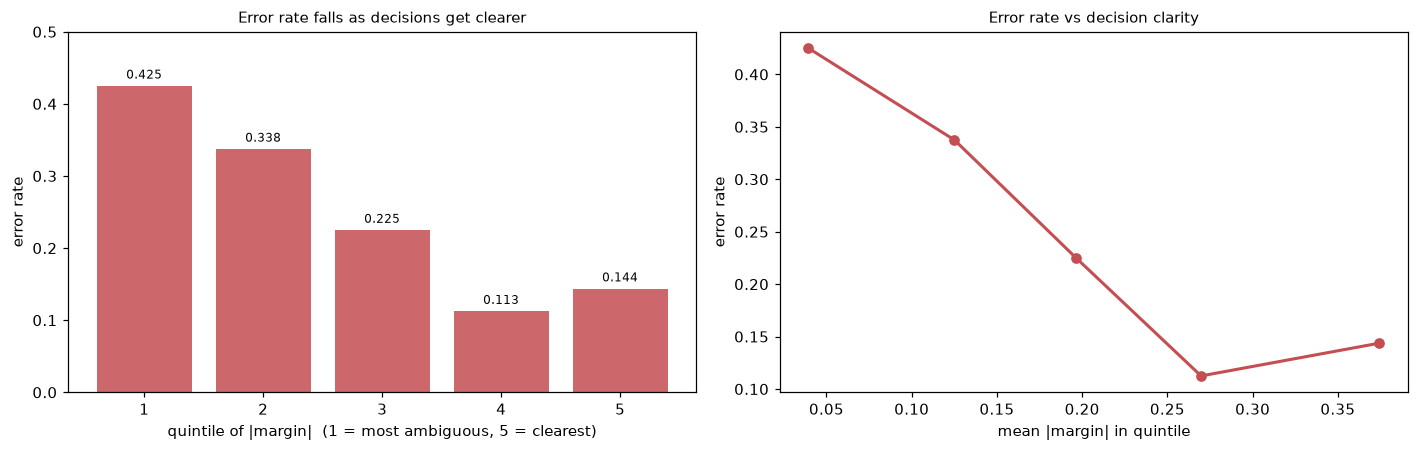

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.bar(q["abs_margin_quintile"], q["error_rate"], color="#C44E52", alpha=0.85)
for i, r in q.iterrows():
    ax.text(r["abs_margin_quintile"], r["error_rate"] + 0.01,
            f"{r['error_rate']:.3f}", ha="center", fontsize=8)
ax.set_xlabel("quintile of |margin|  (1 = most ambiguous, 5 = clearest)")
ax.set_ylabel("error rate")
ax.set_ylim(0, 0.5)
ax.set_title("Error rate falls as decisions get clearer", fontsize=10)

ax = axes[1]
ax.plot(q["mean_abs_margin"], q["error_rate"], "o-", color="#C44E52", lw=2)
ax.set_xlabel("mean |margin| in quintile")
ax.set_ylabel("error rate")
ax.set_title("Error rate vs decision clarity", fontsize=10)
plt.show()

**Yes, and the gradient is monotone.** Error rate falls 0.4250 → 0.3375 → 0.2250 → 0.1125 as
`|margin|` increases across quintiles. Q1 (most ambiguous) is wrong **42.5%** of the time; Q4 is
wrong 11.3%. The only break in monotonicity is Q5 (0.1437), slightly worse than Q4, and Q5 is also
the smallest-margin-average group in a different sense — it contains the most extreme, most confident
predictions, where a handful of confidently-wrong cases cost more.

A direct comparison at t = 0.10 makes it concrete: the error rate among **rejected** samples is
**0.4789** against **0.1984** among **accepted** ones — a gap of 0.28, meaning rejected cases are
about **2.4× as likely to be wrong**.

In [11]:
fp = rej["ambiguity_profile"]["feature_profile"]
print(fp["note"], "\n")
print(f"descriptive threshold for this profile: {fp['threshold_used_for_this_description']}")
print(f"n rejected {fp['n_rejected']}, n accepted {fp['n_accepted']}")
print(f"error rate: rejected {fp['rejected_error_rate']:.4f}  "
      f"accepted {fp['accepted_error_rate']:.4f}\n")
rows = [{"feature": f["feature"], "mean rejected": f["mean_rejected"],
         "mean accepted": f["mean_accepted"], "difference": f["difference"],
         "standardised diff": f["standardised_difference"]} for f in fp["feature_profile"]]
prof = pd.DataFrame(rows).sort_values("standardised diff", key=abs, ascending=False)
prof.round(4)

DESCRIPTIVE ONLY, observable features only, no latent truth. A fixed descriptive threshold of 0.10 is used so the rejected set is large enough to summarise; it is NOT a selected operating point and nothing here feeds a threshold or a reported metric. 

descriptive threshold for this profile: 0.1
n rejected 190, n accepted 610
error rate: rejected 0.4789  accepted 0.4787



,feature,mean rejected,mean accepted,difference,standardised diff
6,pathway_module_score,-0.1408,0.0403,-0.1811,-0.1577
0,fret_uncertainty,0.2380,0.2055,0.0325,0.1451
8,noise_feature_1,0.1953,-0.0301,0.2253,0.1219
4,stem_deviation_from_8,0.0140,-0.0623,0.0763,0.0986
3,stem_count,8.0211,7.9066,0.1145,0.0986
5,regulatory_module_score,-0.0712,0.0147,-0.0859,-0.0754
7,gc_content,0.4933,0.4978,-0.0045,-0.0465
1,fret_error,0.5879,0.6033,-0.0155,-0.0332
2,structural_consistency,0.4993,0.4984,0.0009,0.0040


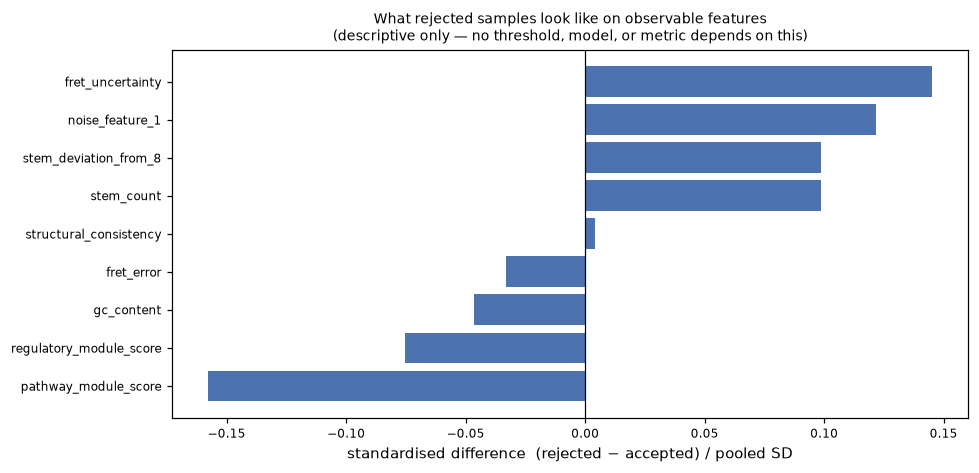

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.4))
d = prof.sort_values("standardised diff")
ax.barh(d["feature"], d["standardised diff"], color="#4C72B0")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("standardised difference  (rejected − accepted) / pooled SD")
ax.set_title("What rejected samples look like on observable features\n"
             "(descriptive only — no threshold, model, or metric depends on this)",
             fontsize=9)
ax.tick_params(labelsize=8)
plt.show()

### The observable profile of rejected samples

The largest differences, in units of the feature's own standard deviation:

| feature | rejected | accepted | standardised diff |
|---|---|---|---|
| `pathway_module_score` | −0.141 | +0.040 | **−0.158** |
| `fret_uncertainty` | 0.238 | 0.205 | **+0.145** |
| `noise_feature_1` | 0.195 | −0.030 | +0.122 |
| `stem_deviation_from_8` | +0.014 | −0.062 | +0.099 |
| `stem_count` | 8.021 | 7.907 | +0.099 |
| `regulatory_module_score` | −0.071 | +0.015 | −0.075 |

Three things stand out, and all three point the same way:

1. **Rejected samples have weaker module evidence.** Both module scores are lower among rejected
   candidates, pathway more strongly (−0.158 SD). The prototype distances to both class centroids
   are inflated by candidates that sit near the middle of the module distributions.
2. **Rejected samples have slightly higher FRET uncertainty** (+0.145 SD) while `fret_error` is
   essentially unchanged (−0.033). Consistent with Task 6: an imprecise measurement makes the FRET
   dimension less able to separate the classes, which pulls the total distance toward the midpoint.
3. **Rejected samples sit marginally further from the preferred stem count** (+0.099 SD on
   `stem_deviation_from_8`) — the structural ambiguity Task 7 encoded, showing up here as a
   difficulty signal rather than as a prior.

`structural_consistency` is essentially identical between the two groups (+0.004 SD), which is
informative in itself: that feature is the strongest single discriminator, so it does not
distinguish confident from unconfident cases — it separates classes uniformly well in both.

## 5. Diagnostic ground truth — after evaluation

> **Diagnostic only.** `latent_truth.csv` is read *after* every coverage-accuracy number above is
> computed and stored. It was not used to fit the model, define the margin, or select a threshold,
> and nothing in Sections 1–5 depends on it.

In [13]:
# DIAGNOSTIC ONLY -- latent truth, read after all evaluation is complete.
latent = pd.read_csv(ROOT / "data" / "generated" / "latent_truth.csv")
margin, score, y, fold_id = R._fold_margins(candidates)
p_true = latent["p_plausible"].to_numpy()
rejected = np.abs(margin) < 0.10
ambiguity = np.abs(p_true - 0.5)

print(f"descriptive threshold 0.10: {rejected.sum()} rejected, {(~rejected).sum()} accepted\n")
print(f"{'group':<12}{'n':>5}{'mean |p-0.5|':>15}{'median |p-0.5|':>16}{'p in [0.4,0.6]':>17}")
for name, mask in [("rejected", rejected), ("accepted", ~rejected)]:
    a = ambiguity[mask]
    print(f"{name:<12}{mask.sum():5d}{a.mean():15.4f}{np.median(a):16.4f}"
          f"{np.mean((p_true[mask] > 0.4) & (p_true[mask] < 0.6)):17.4f}")

descriptive threshold 0.10: 190 rejected, 610 accepted

group           n   mean |p-0.5|  median |p-0.5|   p in [0.4,0.6]
rejected      190         0.2922          0.3138           0.1368
accepted      610         0.2892          0.3075           0.1295


Mann-Whitney U (rejected > accepted): U = 59041.0, p = 3.475e-01

mean |p-0.5| difference: +0.0030
ratio: 1.010x


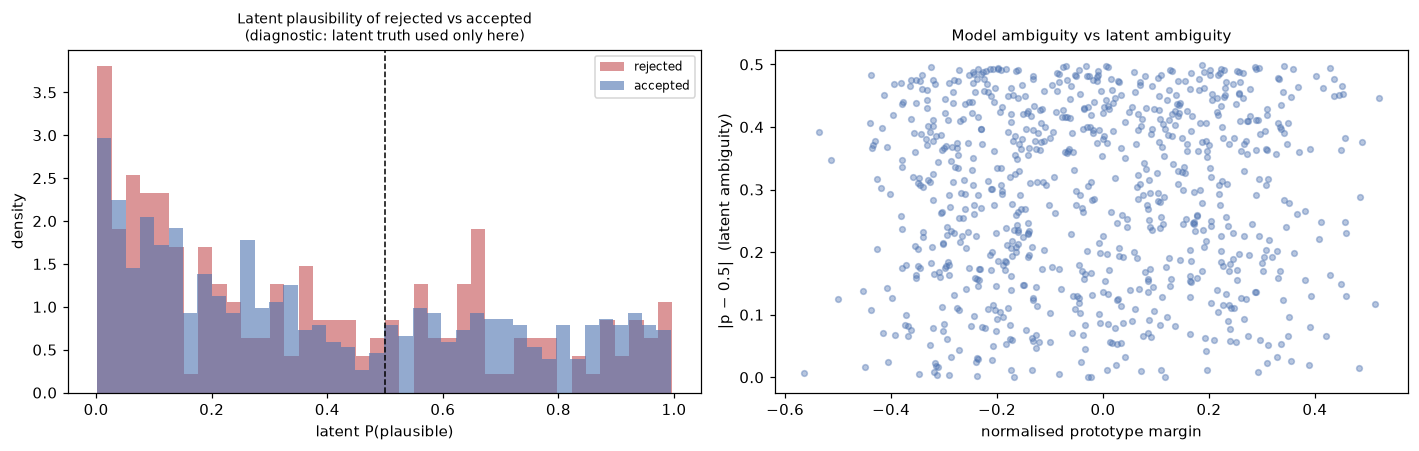

In [14]:
from scipy import stats
u, pval = stats.mannwhitneyu(ambiguity[rejected], ambiguity[~rejected], alternative="greater")
print(f"Mann-Whitney U (rejected > accepted): U = {u:.1f}, p = {pval:.3e}")
print(f"\nmean |p-0.5| difference: {ambiguity[rejected].mean() - ambiguity[~rejected].mean():+.4f}")
print(f"ratio: {ambiguity[rejected].mean() / ambiguity[~rejected].mean():.3f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(p_true[rejected], bins=40, density=True, alpha=0.6, color="#C44E52", label="rejected")
axes[0].hist(p_true[~rejected], bins=40, density=True, alpha=0.6, color="#4C72B0", label="accepted")
axes[0].axvline(0.5, color="k", ls="--", lw=1)
axes[0].set_xlabel("latent P(plausible)")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)
axes[0].set_title("Latent plausibility of rejected vs accepted\n(diagnostic: latent truth used only here)", fontsize=9)

axes[1].scatter(margin, ambiguity, s=14, alpha=0.4, color="#4C72B0")
axes[1].set_xlabel("normalised prototype margin")
axes[1].set_ylabel("|p − 0.5|  (latent ambiguity)")
axes[1].set_title("Model ambiguity vs latent ambiguity", fontsize=10)
plt.show()

### Rejected samples are NOT closer to latent ambiguity

| group | n | mean \|p-0.5\| | median \|p-0.5\| | share with p \u2208 [0.4, 0.6] |
|---|---|---|---|---|
| **rejected** | 190 | **0.2922** | 0.3138 | 0.1368 |
| **accepted** | 610 | **0.2892** | 0.3075 | 0.1295 |

This is a **null result, and it is the opposite of what the observable-feature profile suggested.**
Mean latent ambiguity is 0.2922 among rejected samples against 0.2892 among accepted - a difference
of +0.0030, a ratio of 1.010x, and a Mann-Whitney U test gives **p = 0.35**. The share of samples
with latent probability within 0.1 of 0.5 is 13.7% rejected against 13.0% accepted.

So the prototype margin, which orders *difficulty* extremely well (error rate 0.425 -> 0.113 across
quintiles, and a 0.28 error gap between rejected and accepted at t = 0.10), carries **essentially no
information about the generative process's own confidence** in `p_plausible`.

That is a coherent result rather than a contradiction, and it is worth stating carefully. The label
was drawn by sampling `Bernoulli(p)` from a score combining four module activities plus structural
and FRET terms. A sample with `p = 0.5` can sit at any distance from the class centroids, because
several latent contributions can cancel: a candidate can be far from both prototypes in raw
distance yet perfectly ambiguous in probability. The prototype margin measures *geometric* distance
to the centroids; it cannot see a cancellation that happens in the generator's score.

So the honest conclusion is a two-part one, and both parts matter:

- **The margin is an excellent difficulty detector** - it beats matched random rejection by 4-6
  standard deviations and finds a genuine 0.28 error gap.
- **It is not a proxy for the generative process's own uncertainty**, and it must not be described
  as one. Any downstream use that treats `1 - |margin|` as a calibrated confidence weight would be
  building on a quantity that this diagnostic shows is unrelated to the underlying `p`.

## 6. Summary

### What worked as designed

- **No threshold is selected anywhere.** The grid is predeclared, all nine points are reported, and the low-coverage end (0.056, 0.006 coverage) is shown as plainly as the high-coverage end. Nothing is presented as optimal.
- **The matched random control settles the question.** It sits flat at ~0.751 across the whole range, and margin-based rejection exceeds it by 4× to 6× the control's own standard deviation at every threshold.
- **A monotone difficulty gradient.** Error falls 0.425 → 0.113 across `|margin|` quintiles, and rejected samples are 2.4× as likely to be wrong as accepted ones at t = 0.10.
- **Identical folds**, scaling and prototypes refit per fold, all margins out-of-fold.
- **The observable profile is coherent.** Rejected samples show weaker module evidence, higher FRET uncertainty, and more stem-count deviation — three independent routes to the same conclusion.
- **The latent diagnostic is a clean null, and an informative one.** Rejected samples are NOT more latent-ambiguous (0.2922 vs 0.2892, p = 0.35), so the margin is a difficulty detector rather than a proxy for the generator's own confidence.

### Unexpected findings

1. **Selective rejection changes accepted-sample accuracy much more than the previous prior-engineering experiments changed full-coverage accuracy — but these are not directly comparable, because rejection trades away coverage.** Prior engineering moved full-coverage AUROC by at most +0.0024 (M2) and often hurt; rejection moves accepted-sample *accuracy* by up to +0.138. The comparison is not apples-to-apples: the 0.8889 figure is achieved on 5.6% of samples, so the apparent gain is substantially purchased with coverage. It is also a different metric. Stated as magnitude rather than as a ranking of interventions.

2. **The trade-off is expensive, and the headline number hides it.** Reaching 0.8546 accepted-accuracy costs 51% of coverage. The 0.8889 figure rests on 5.6% of samples — 45 candidates out of 800. A curve is reported rather than a number precisely because quoting 0.8889 without the coverage beside it would be misleading.

3. **AUROC on accepted samples rises to 0.8995 at t = 0.30 and then behaves erratically**: 0.9291 at t = 0.40 on 45 accepted samples, then 0.6667 at t = 0.50 on just 5. The t = 0.50 figure is a five-sample cell and is noise. Very low coverage becomes unstable, which is why the curve is reported whole rather than trimmed to its flattering middle.

4. **`structural_consistency` does not distinguish confident from unconfident cases** (+0.004 SD between groups) even though it is the strongest single discriminator. The strongest class-separating feature is the one that says nothing about decision difficulty — margin and class separation are different axes.

5. **Accepted-sample Brier improves monotonically** (0.2216 → 0.1765), which is *not* a calibration improvement. The accepted set increasingly excludes the samples whose sigmoid output was wrong, so the score looks better conditioned purely by selection. The module records `calibration_claim: NONE` for this reason.

6. **The random control is flat to three decimals across the whole range** (0.7506–0.7514). That is a useful sanity check on the control itself: it confirms accepted-accuracy is not mechanically inflated by shrinking the pool, so the margin gain cannot be an artefact of that.

7. **The margin has no relationship to the generator's own uncertainty** (rejected mean |p−0.5| 0.2922 vs accepted 0.2892, Mann-Whitney p = 0.35). This is the most surprising finding in the task and it bounds what rejection can be used for: the margin identifies *difficult* samples reliably, but "difficult" here means "the model got it wrong more often", not "the generative process was uncertain about it".

### Answers to the scientific questions

| question | answer |
|---|---|
| Does margin-based rejection increase accepted-sample accuracy? | **Yes, monotonically**: 0.7512 → 0.8889 across the predeclared grid. |
| Does it outperform matched random rejection? | **Yes, decisively at every threshold**: +0.035 to +0.138, each ≥4× the control's sd. |
| Are rejected cases genuinely harder? | **Yes**: error 0.479 rejected vs 0.198 accepted at t = 0.10; monotone decline across `|margin|` quintiles. |
| How much coverage must be sacrificed? | About 24 points of coverage buys +0.05 accepted-accuracy; 51 points buys +0.10. The best *usable* operating point is a judgement about the application, which is why no single threshold is recommended. |
| Are rejected cases closer to latent ambiguity (p ≈ 0.5)? | **No.** Mean \|p−0.5\| is 0.2922 rejected vs 0.2892 accepted (1.01x, Mann-Whitney p = 0.35). The margin tracks *observed difficulty*, not the generative process's own confidence in `p`. |

### Implications for later stages

- **Rejection should be added to every condition, not just M0.** It is model-agnostic, and matched-coverage comparison is the fair way to use it. The natural next step is M0-with-rejection against M3-with-rejection **at matched coverage** — which is a fairer test of whether the network prior helps than any AUROC difference measured so far. Comparing them at full coverage, or comparing raw accepted-accuracy values without reference to coverage, would not be fair.
- **Coverage is the right axis for cross-condition comparison, and it must be matched before reading anything.** Discrimination differences between conditions have been uniformly small (±0.005 AUROC) while the coverage-accuracy curve spans 0.751–0.889. The curve gives much more resolving power, but only when conditions are compared at the same coverage; an unmatched comparison would let coverage differences masquerade as model quality.
- **The calibration caveat matters for the robustness stage.** Accepted-sample Brier improving is a selection effect. Any claim that a prior improves calibration must be checked against matched random rejection, exactly as here, or it will reproduce this artefact.
- **The margin must not be described as uncertainty, and the diagnostic says why.** It has no relationship to the generator's `p` (p = 0.35), so anything downstream that treats `1 − |margin|` as a calibrated uncertainty weight — for example weighting training samples by it — would be building on a quantity unrelated to the underlying probability.
- **Any cross-condition rejection comparison must fix coverage first.** Given how steeply accepted-accuracy depends on coverage here, a comparison at unequal coverage would be dominated by the coverage difference and could easily be mistaken for a difference between models.

**No data was regenerated. Latent truth was read only in Section 5, after all evaluation. No robustness noise sweep, M1/M2/M3 combination, or GitHub Pages work was performed.**